# Task 1. Exploratory analysis of the Spiff price series

Task 1 in the project asks for a thorough analysis of the seven series, with particular attention to patterns within each series, relationships between the series, and whether the assets can be grouped. The PDF also suggests that returns should be the main working object, since price levels are likely to be nonstationary.

This notebook is therefore organized around three questions:

1. What do the individual price and return series look like?
2. What serial dependence remains after transforming prices to returns?
3. Which assets move together strongly enough to justify grouping?


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from statsmodels.graphics.gofplots import qqplot

repo_root = Path.cwd()
sys.path.append(str(repo_root.parent))

from config.plot_config import plot_config
from Subtasks.series_analysis import PriceAnalysis

output = plot_config() / "task1"
output.mkdir(exist_ok=True)

## 1. Load the raw data


In [2]:
raw_data = PriceAnalysis.from_csv("spiff_data-2.csv")
raw_prices = raw_data.prices
raw_prices.iloc[:5].reset_index().to_latex(output / "DataExample.tex", index=False)
raw_prices.head()



,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
1,6.154653,2.794285,2.136536,10.653684,3.324896,3.896149,7.755880
2,6.189623,2.843068,2.113582,10.674465,3.355736,3.899915,7.781310
3,6.168641,2.839644,2.116336,10.822372,3.336461,3.897404,7.886205
4,6.156401,2.823384,2.096137,10.848804,3.288274,3.901170,7.848061
5,6.124929,2.832798,2.099810,10.860731,3.303694,3.905355,7.883026


## 2. Data quality and cleaning

Before studying any time-series structure, we first check whether the raw dataset contains implausible observations or systematic missingness. This is essential because a few corrupted rows can dominate sample means, variances, correlations, and autocorrelations.


In [3]:
raw_overview = raw_data.overview()
print(f"Raw shape: {raw_prices.shape}")
display(raw_overview)


Raw shape: (5456, 7)


,dtype,missing_values,missing_share
gurkor,float64,250,0.045821
guitars,float64,250,0.045821
slingshots,float64,250,0.045821
stocks,float64,250,0.045821
sugar,float64,250,0.045821
water,float64,250,0.045821
tranquillity,float64,250,0.045821


The raw price plot is useful for spotting level shifts, obvious trends, and values that are completely out of scale with their neighbors.


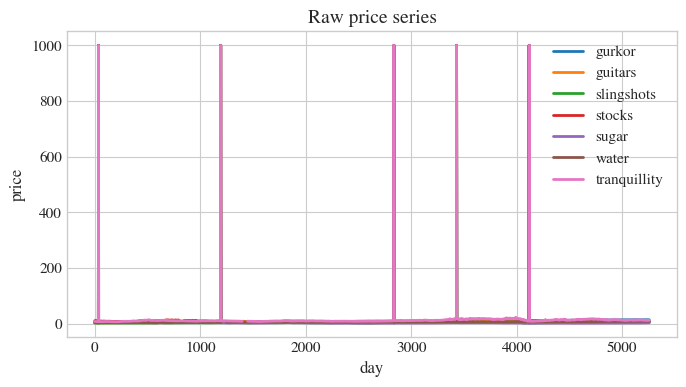

In [4]:
fig, ax = plt.subplots()
for column in raw_prices.columns:
    ax.plot(raw_prices.index, raw_prices[column], label=column)
ax.set_title("Raw price series")
ax.set_xlabel("day")
ax.set_ylabel("price")
ax.legend()

plt.tight_layout()
plt.savefig(output / "raw_price_series.png", bbox_inches="tight")
plt.show()


Rows where every asset takes the exact value 1000 are best interpreted as placeholders or corrupted observations rather than genuine prices. Keeping them would create artificial jumps in both returns and dependence measures, so they are removed before the main analysis.


In [5]:
placeholder_value = 1_000
placeholder_rows = raw_data.placeholder_rows(placeholder_value)
cleaned_data = raw_data.clean(placeholder_value)
cleaned_prices = cleaned_data.prices
cleaned_overview = pd.DataFrame(
    {
        "missing_values_after_cleaning": cleaned_prices.isna().sum(),
        "missing_share_after_cleaning": cleaned_prices.isna().mean(),
    }
)

print(f"Rows where all assets equal {placeholder_value}: {len(placeholder_rows)}")
display(placeholder_rows)
display(cleaned_overview)


Rows where all assets equal 1000: 5


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
36,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
1194,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
2836,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
3430,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
4118,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0


,missing_values_after_cleaning,missing_share_after_cleaning
gurkor,255,0.046738
guitars,255,0.046738
slingshots,255,0.046738
stocks,255,0.046738
sugar,255,0.046738
water,255,0.046738
tranquillity,255,0.046738


Each series then contains one internal 50-day gap, and all series share a final block of 200 missing values. That structure matters for later tasks: interpolation must handle one interior gap per asset, while extrapolation must handle a shared missing tail.


,block_1,block_2
gurkor,199-248 (50 days),5257-5456 (200 days)
guitars,399-448 (50 days),5257-5456 (200 days)
slingshots,599-648 (50 days),5257-5456 (200 days)
stocks,799-848 (50 days),5257-5456 (200 days)
sugar,999-1048 (50 days),5257-5456 (200 days)
water,1199-1248 (50 days),5257-5456 (200 days)
tranquillity,1399-1448 (50 days),5257-5456 (200 days)


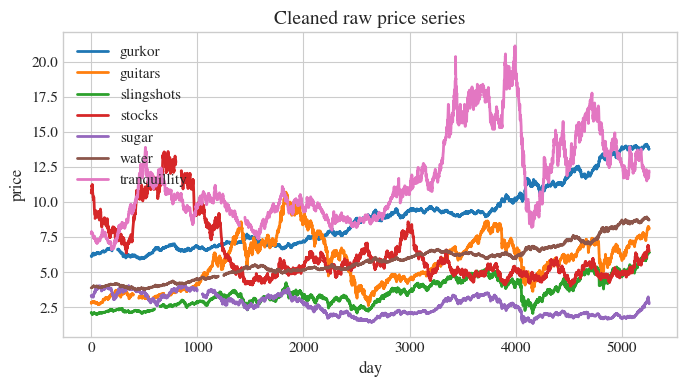

In [6]:
missing_blocks = cleaned_data.missing_summary()
display(missing_blocks)

fig, ax = plt.subplots()
for column in cleaned_prices.columns:
    ax.plot(cleaned_prices.index, cleaned_prices[column], label=column)
ax.set_title("Cleaned raw price series")
ax.set_xlabel("day")
ax.set_ylabel("price")
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(output / "cleaned_raw_price_series.png", bbox_inches="tight")
plt.show()


## 3. Transformations and analysis settings

The project statement explicitly suggests using returns rather than raw prices for most of the analysis. Let $X_t$ denote the price at time $t$. We work with log-returns

$$
r_t = \log X_t - \log X_{t-1},
$$



In [7]:
log_return_data = cleaned_data.log_returns
absolute_log_return_data = cleaned_data.absolute_log_returns
squared_log_return_data = cleaned_data.squared_log_returns
rolling_window = 30
max_lag = 30
group_threshold = 0.3


## 4. Within-series patterns

Task 1 asks first what patterns exist within the individual series. We therefore begin with raw prices, transformed returns, distributional shape, and rolling summaries of the first two moments.


### Price levels and log-returns

The left panels show the cleaned price levels. These are useful for checking trend, persistence, structural breaks, and changing scale. The right panels show the corresponding log-returns, which should look more stable if differencing removes the main nonstationary component.


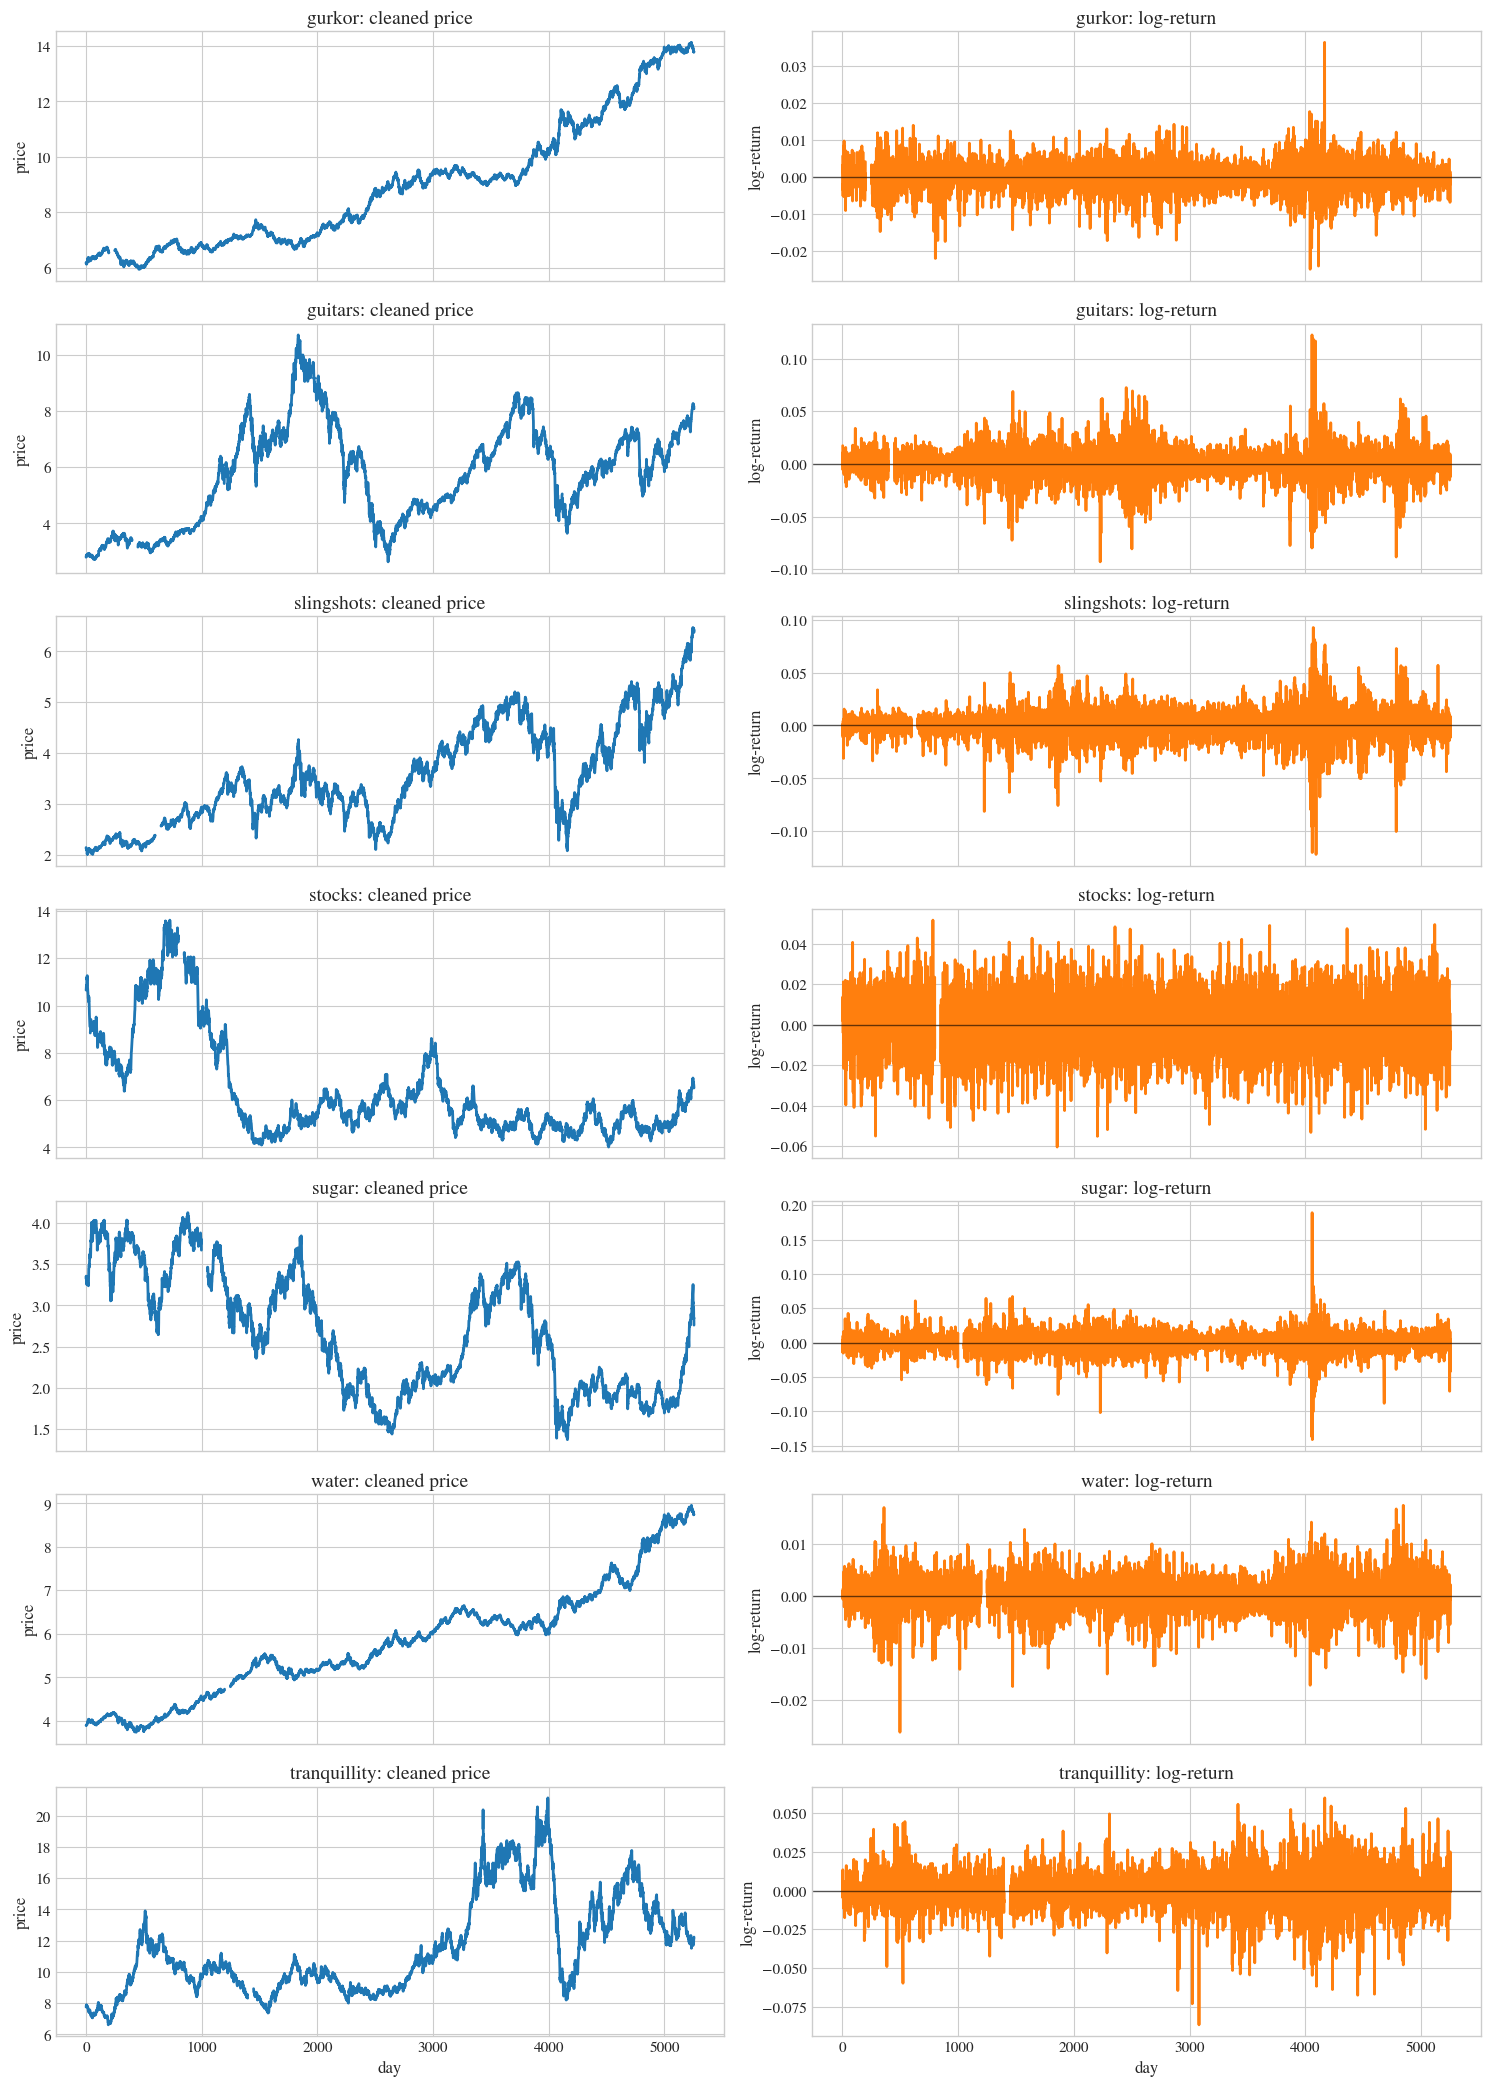

In [8]:
fig, axes = plt.subplots(len(cleaned_prices.columns), 2, figsize=(15, 3 * len(cleaned_prices.columns)), sharex=True, squeeze=False)

for row, column in enumerate(cleaned_prices.columns):
    axes[row, 0].plot(cleaned_prices.index, cleaned_prices[column], color="tab:blue")
    axes[row, 0].set_title(f"{column}: cleaned price")
    axes[row, 0].set_ylabel("price")

    axes[row, 1].plot(log_return_data.index, log_return_data[column], color="tab:orange")
    axes[row, 1].axhline(0, color="black", linewidth=1, alpha=0.6)
    axes[row, 1].set_title(f"{column}: log-return")
    axes[row, 1].set_ylabel("log-return")

for ax in axes[-1, :]:
    ax.set_xlabel("day")

plt.tight_layout()
plt.savefig(output / "price_levels_and_log_returns.png", bbox_inches="tight")
plt.show()


### Distributional shape and rolling stability

The histogram and QQ-plot focus on the one-period distribution of $r_t$. The rolling mean and rolling variance then ask whether the transformed series look approximately stable over time, which is important if a stationary model is to be plausible later.


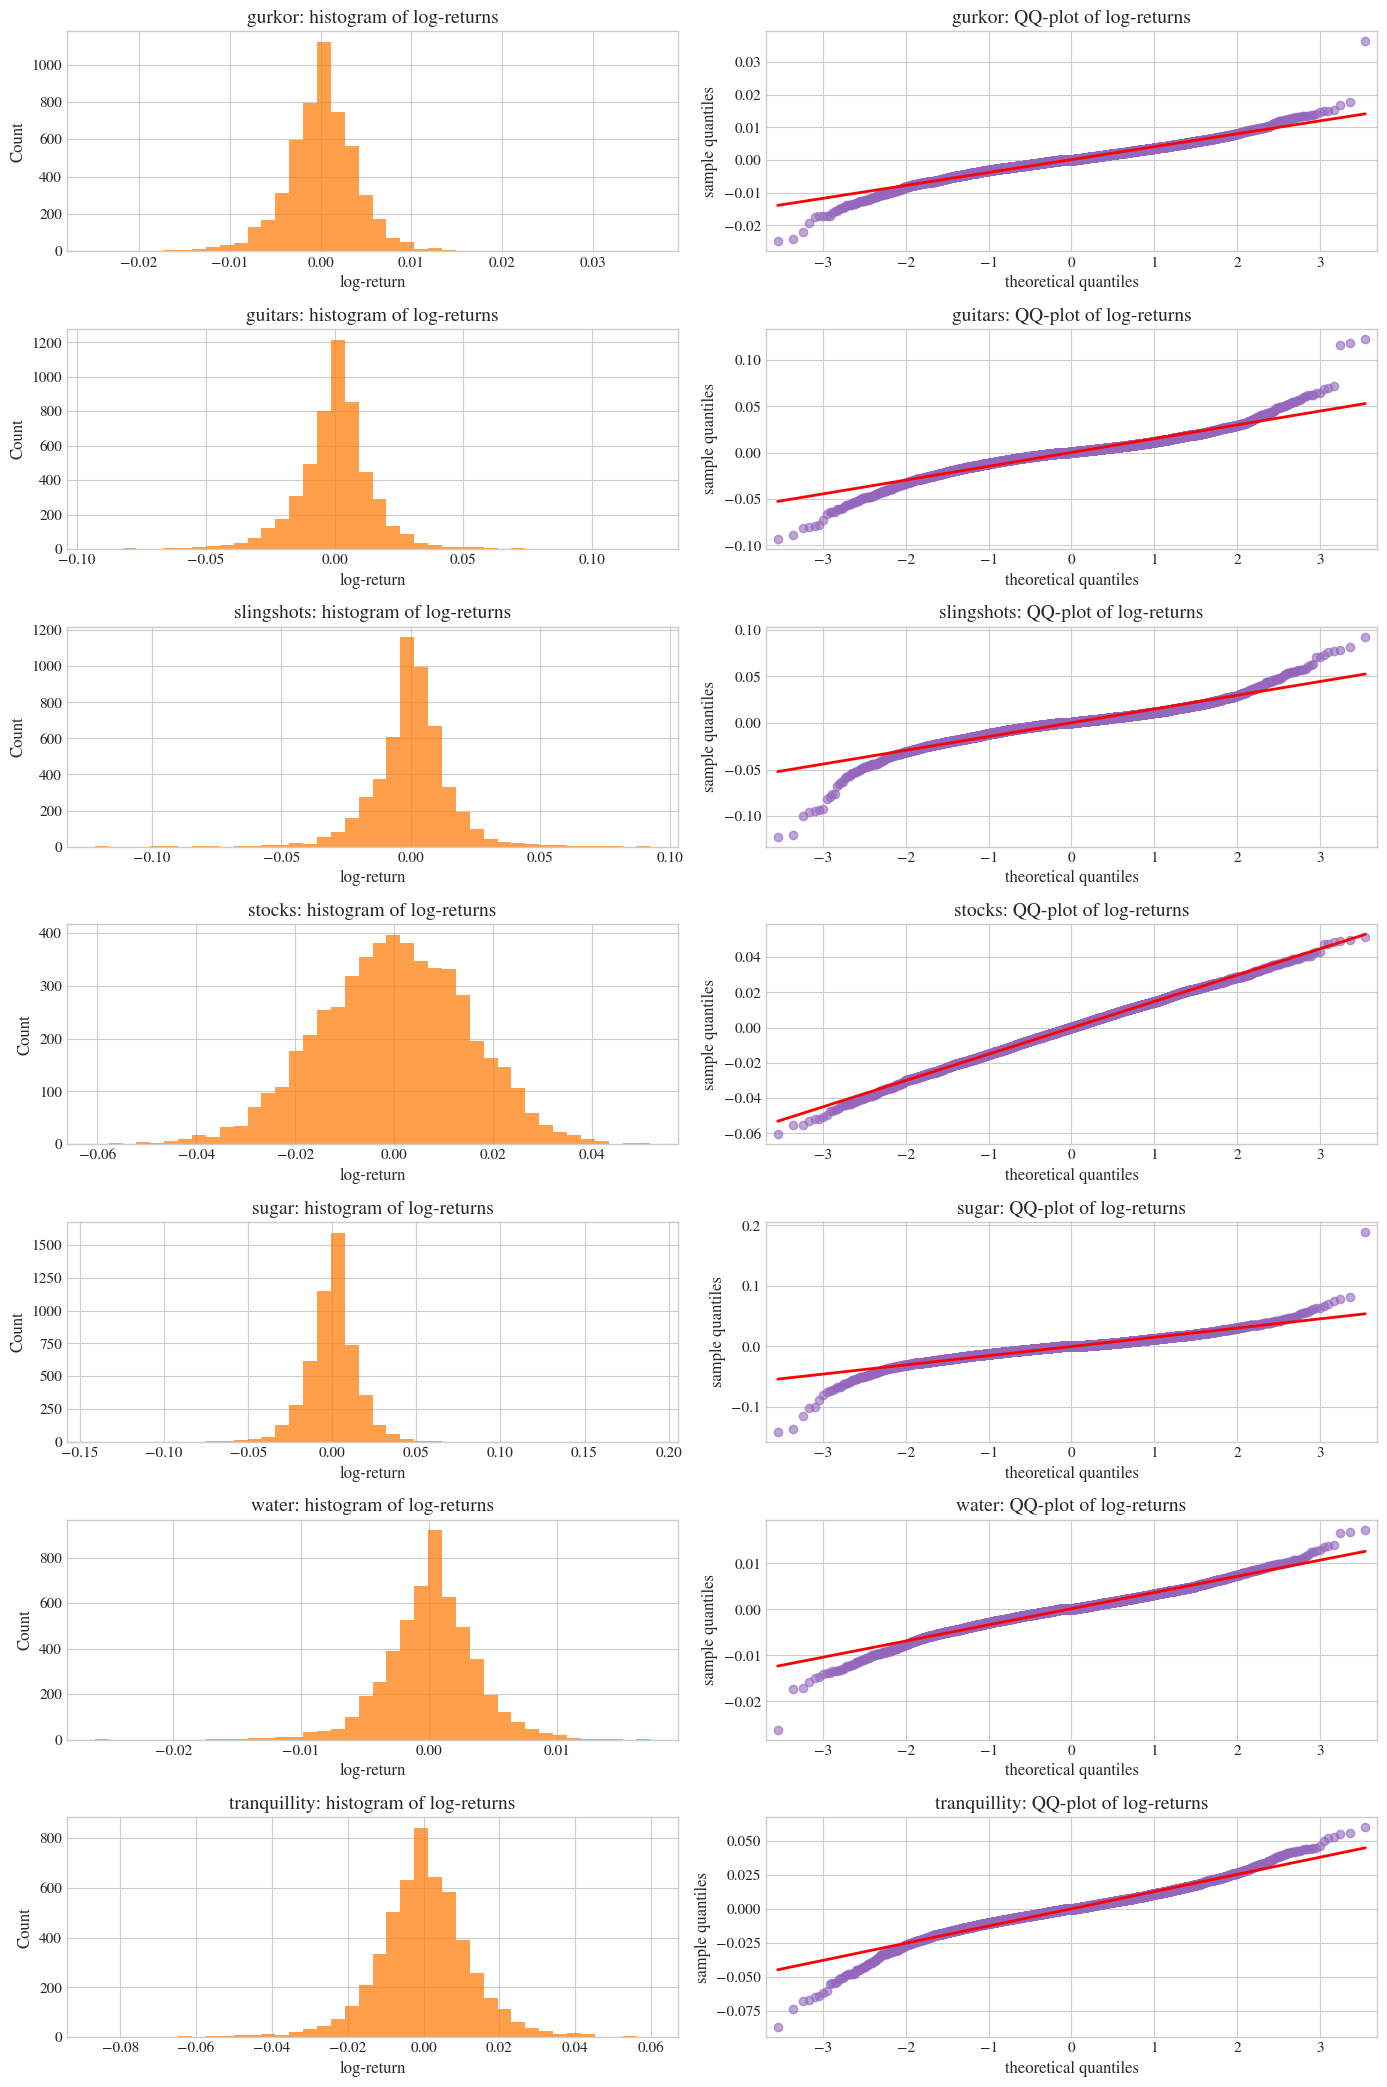

In [9]:
fig, axes = plt.subplots(len(cleaned_prices.columns), 2, figsize=(14, 3 * len(cleaned_prices.columns)), squeeze=False)

for row, column in enumerate(cleaned_prices.columns):
    series = log_return_data[column].dropna()

    sns.histplot(series, bins=40, ax=axes[row, 0], color="tab:orange", edgecolor=None)
    axes[row, 0].set_title(f"{column}: histogram of log-returns")
    axes[row, 0].set_xlabel("log-return")

    qqplot(series, line="s", ax=axes[row, 1], markerfacecolor="tab:purple", markeredgecolor="tab:purple", alpha=0.6)
    axes[row, 1].set_title(f"{column}: QQ-plot of log-returns")
    axes[row, 1].set_xlabel("theoretical quantiles")
    axes[row, 1].set_ylabel("sample quantiles")

plt.tight_layout()
plt.savefig(output / "log_return_histograms_qqplots.png", bbox_inches="tight")
plt.show()


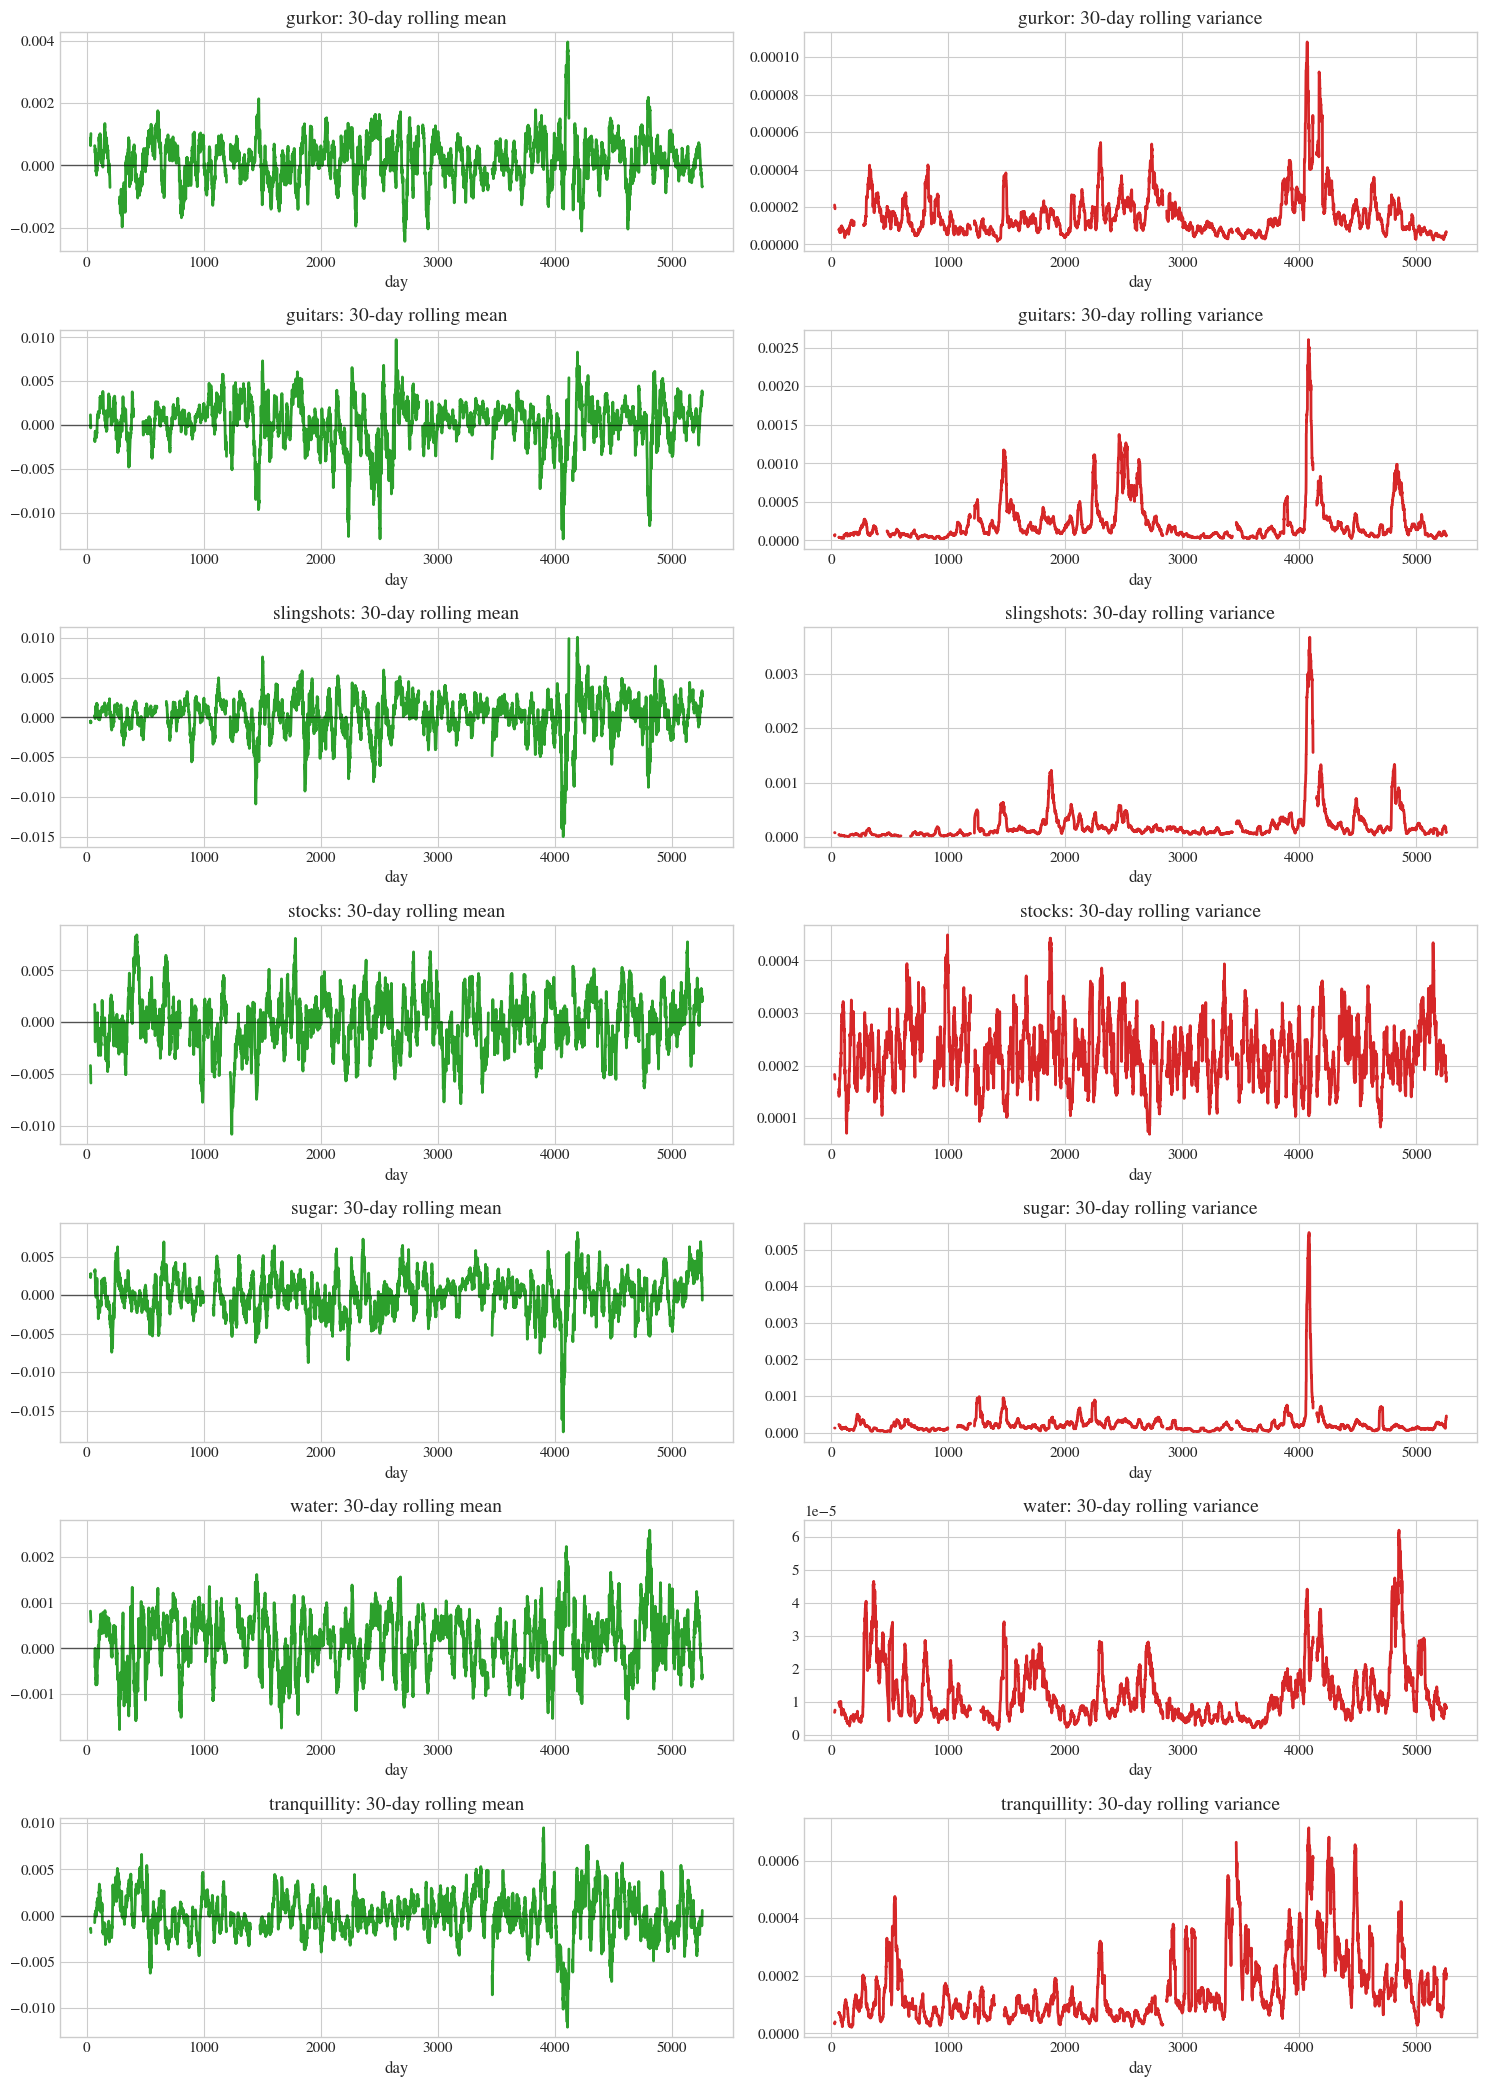

In [10]:
rolling_mean_30 = cleaned_data.rolling_mean(window=rolling_window)
rolling_variance_30 = cleaned_data.rolling_variance(window=rolling_window)

fig, axes = plt.subplots(len(cleaned_prices.columns), 2, figsize=(15, 3 * len(cleaned_prices.columns)), squeeze=False)

for row, column in enumerate(cleaned_prices.columns):
    axes[row, 0].plot(rolling_mean_30.index, rolling_mean_30[column], color="tab:green")
    axes[row, 0].axhline(0, color="black", linewidth=1, alpha=0.6)
    axes[row, 0].set_title(f"{column}: {rolling_window}-day rolling mean")
    axes[row, 0].set_xlabel("day")

    axes[row, 1].plot(rolling_variance_30.index, rolling_variance_30[column], color="tab:red")
    axes[row, 1].set_title(f"{column}: {rolling_window}-day rolling variance")
    axes[row, 1].set_xlabel("day")

plt.tight_layout()
plt.savefig(output / "rolling_mean_variance.png", bbox_inches="tight")
plt.show()


## 5. Serial dependence and volatility clustering

A thorough Task 1 analysis should check whether dependence remains after transforming prices to returns. We therefore plot the autocorrelation function (ACF) beside the partial autocorrelation function (PACF) for raw prices, log-returns, and absolute log-returns, and then summarize the same issue with Ljung-Box tests.


### ACF and PACF of the cleaned price levels

For a transformed series $z_t$, the sample autocorrelation at lag $k$ is

$$
\hat\rho_k = \frac{\sum_{t=k+1}^T (z_t - \bar z)(z_{t-k} - \bar z)}{\sum_{t=1}^T (z_t - \bar z)^2}.
$$

The PACF then isolates the direct contribution of lag $k$ after controlling for lags $1, \ldots, k-1$. If the raw price series are nonstationary, their ACFs should decay slowly rather than cutting off quickly, while the PACF should not show a clean short-order cutoff.


In [11]:
def plot_dual_serial_correlation_grid(data, analysis, max_lag, label, acf_color="tab:blue", pacf_color="tab:green"):
    lags = np.arange(max_lag + 1)
    fig, axes = plt.subplots(len(data.columns), 2, figsize=(15, 2.8 * len(data.columns)), squeeze=False)

    for row, column in enumerate(data.columns):
        series = data[column].dropna()
        acf_values = analysis.sample_acf(series, max_lag=max_lag)
        pacf_values = analysis.sample_pacf(series, max_lag=max_lag)
        confidence_band = 1.96 / np.sqrt(len(series))

        for ax, values, title, color in [
            (axes[row, 0], acf_values, "ACF", acf_color),
            (axes[row, 1], pacf_values, "PACF", pacf_color),
        ]:
            ax.axhline(0, color="black", linewidth=1)
            ax.axhline(confidence_band, color="tab:red", linestyle="--", linewidth=1)
            ax.axhline(-confidence_band, color="tab:red", linestyle="--", linewidth=1)
            ax.stem(lags, values, basefmt=" ", linefmt=color, markerfmt="o")
            ax.set_title(f"{column}: {title} of {label}")
            ax.set_ylabel(title)
            ax.set_xlim(-0.5, max_lag + 0.5)

    for ax in axes[-1, :]:
        ax.set_xlabel("lag")

    plt.tight_layout()
    safe_label = label.lower().replace(" ", "_").replace("-", "_")
    plt.savefig(output / f"acf_pacf_{safe_label}.png", bbox_inches="tight")
    plt.show()


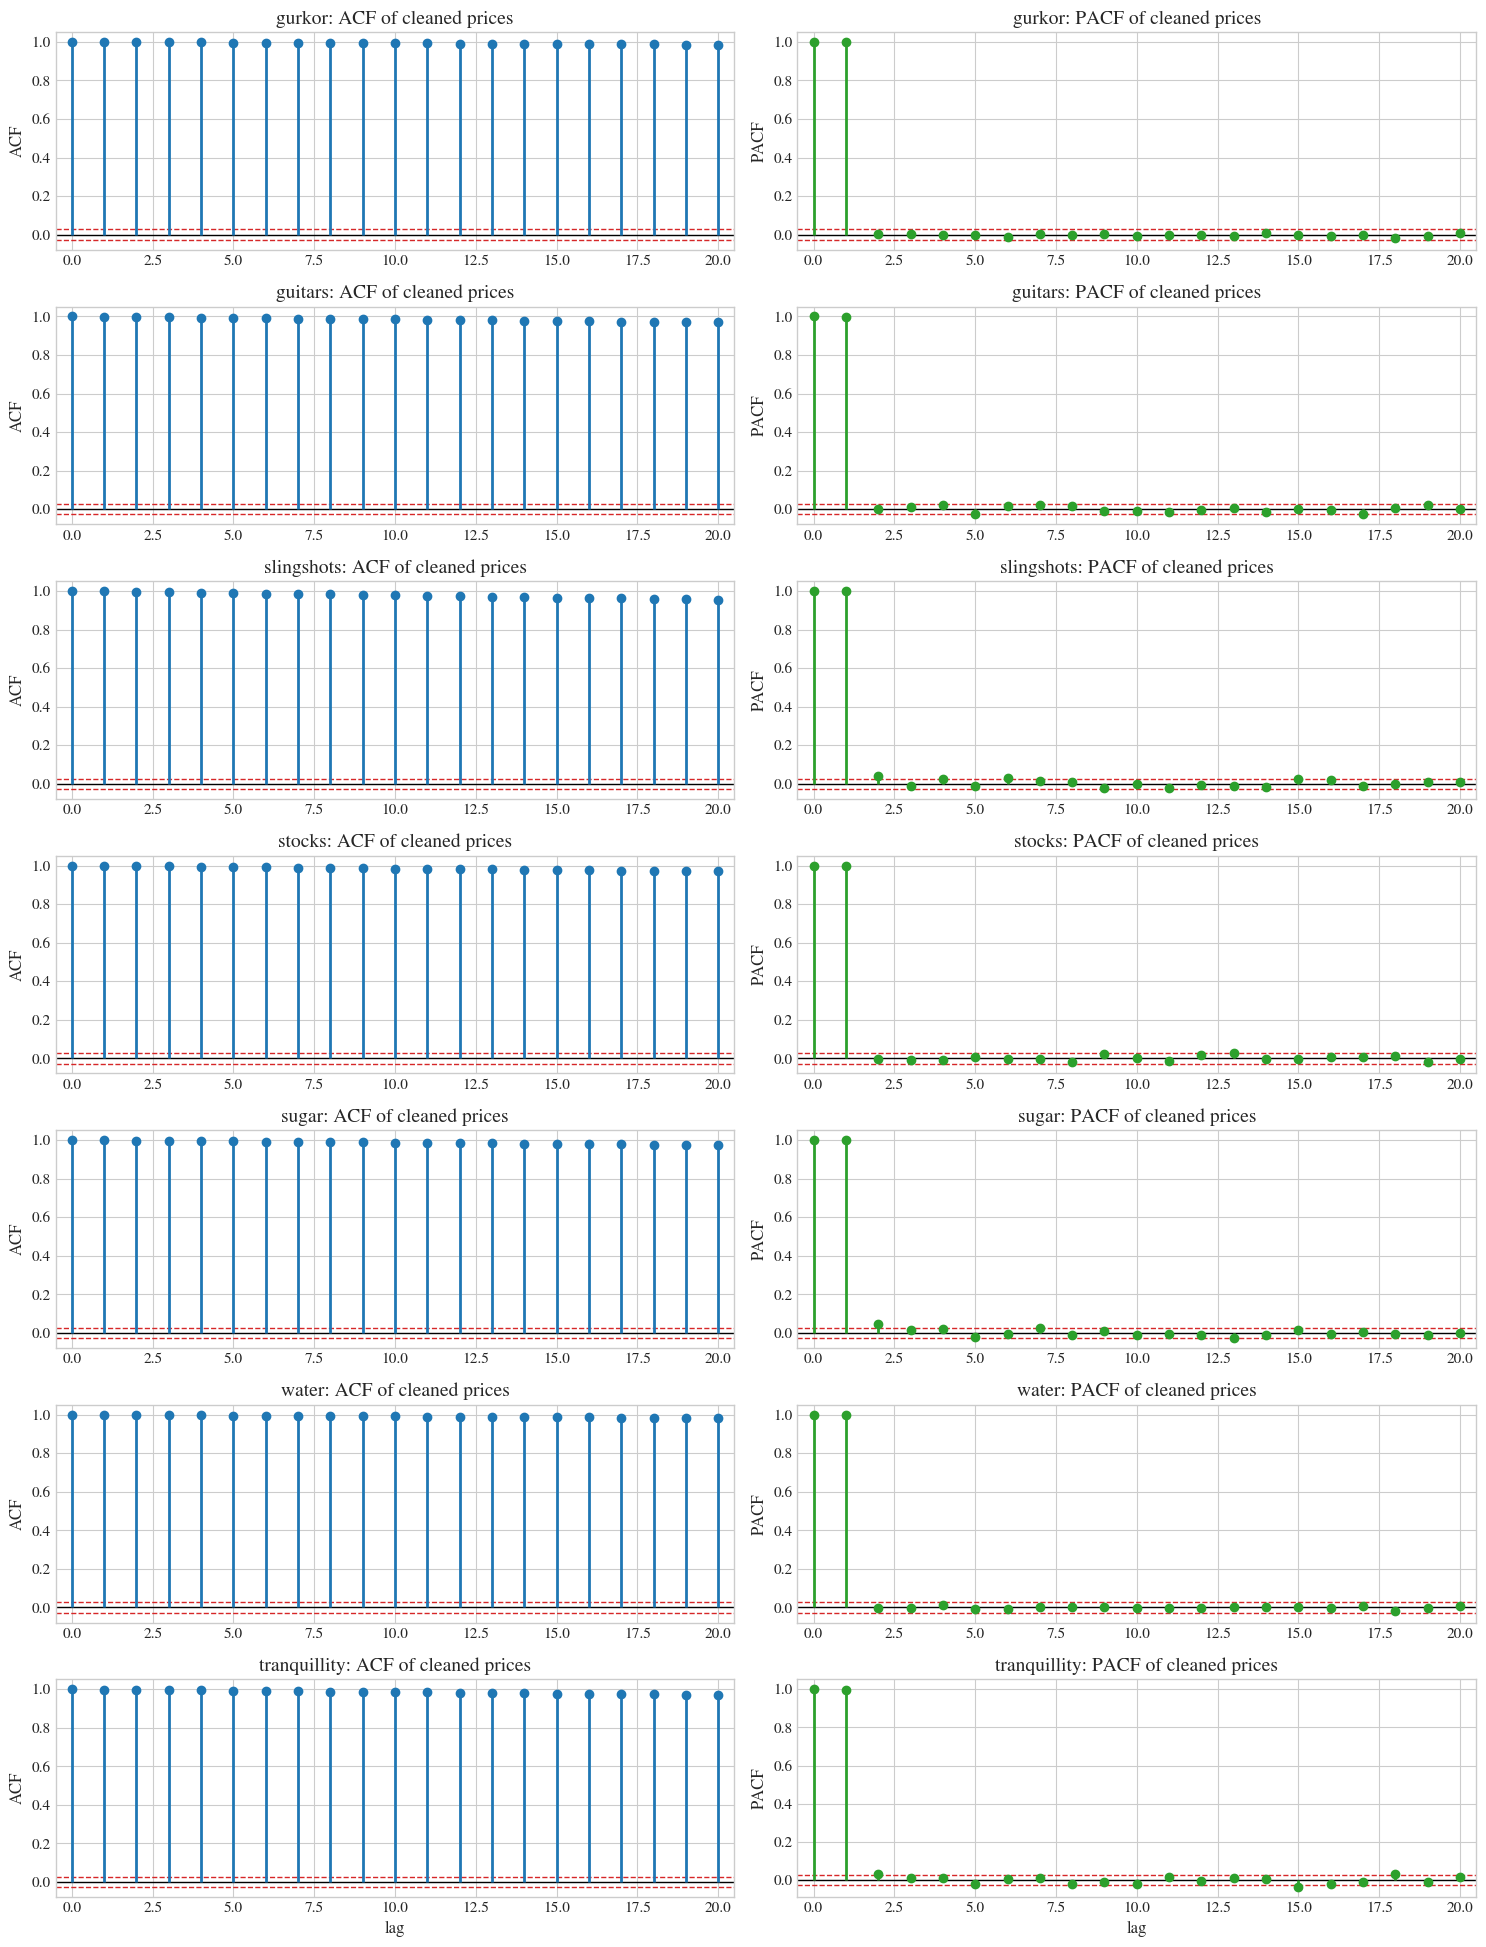

In [12]:
plot_dual_serial_correlation_grid(
    cleaned_prices,
    cleaned_data,
    max_lag=20,
    label="cleaned prices",
    acf_color="tab:blue",
    pacf_color="tab:green",
)


The side-by-side price-level plots make the same persistence point in two ways: the ACF decays very slowly, and the PACF does not show a sharp low-order cutoff. This supports the view that the levels are highly persistent rather than well described by a short stationary AR process. There is also no convincing seasonal pattern.


### ACF and PACF of log-returns and absolute log-returns

The return ACF checks linear dependence in $r_t$, while the return PACF shows whether any dependence remains after controlling for shorter lags. The same side-by-side comparison for $|r_t|$ checks whether return magnitudes have persistent direct short-lag dependence, which is a standard signal of volatility clustering.


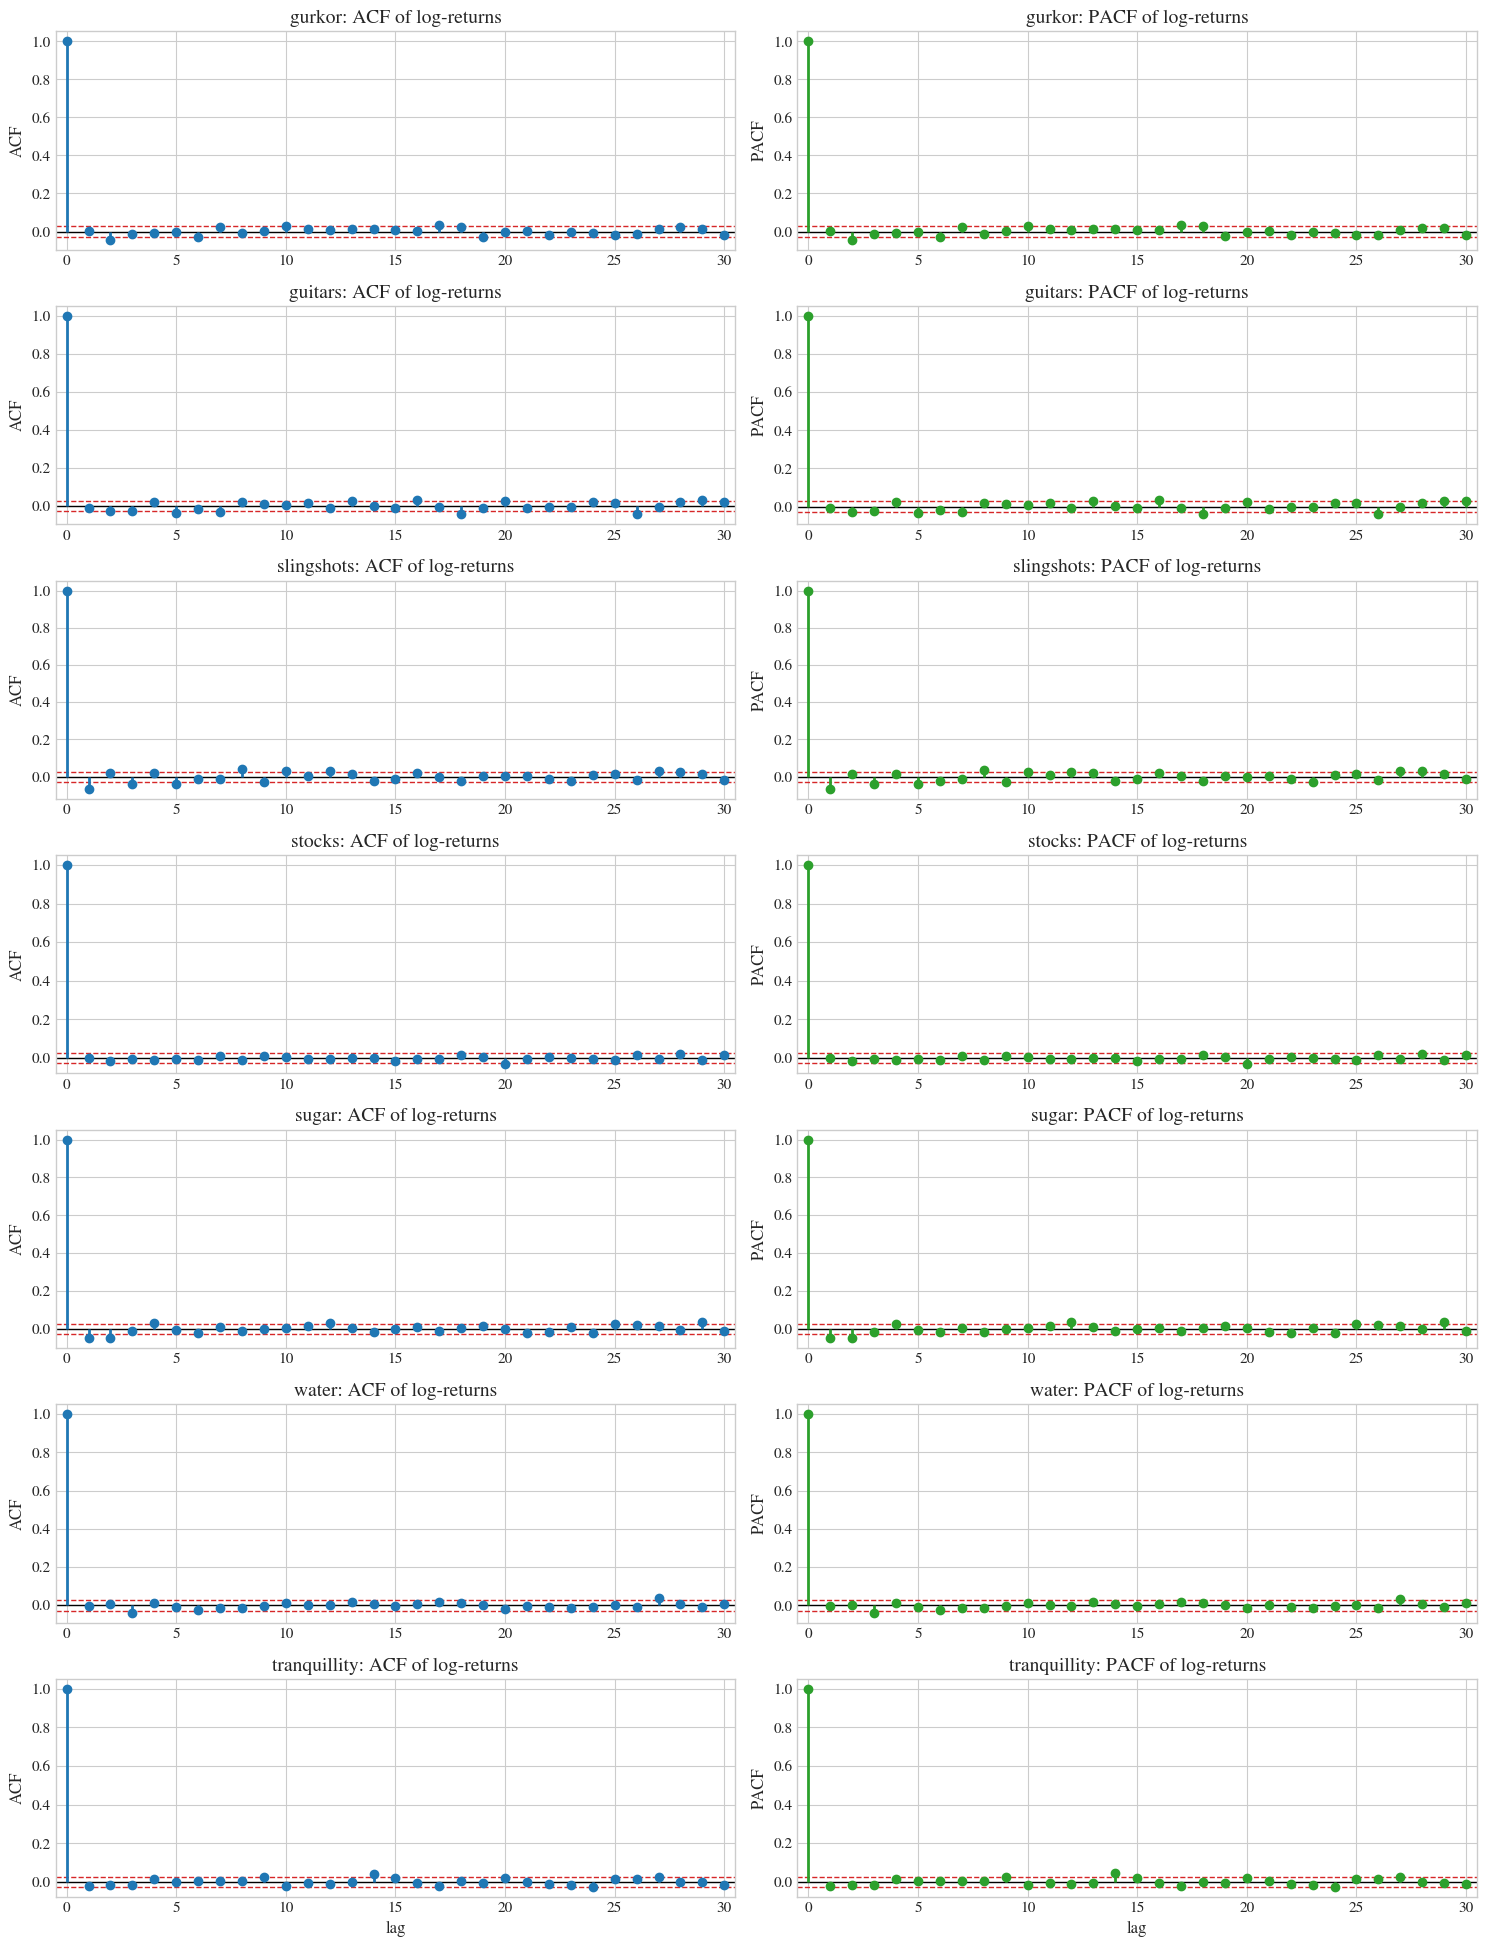

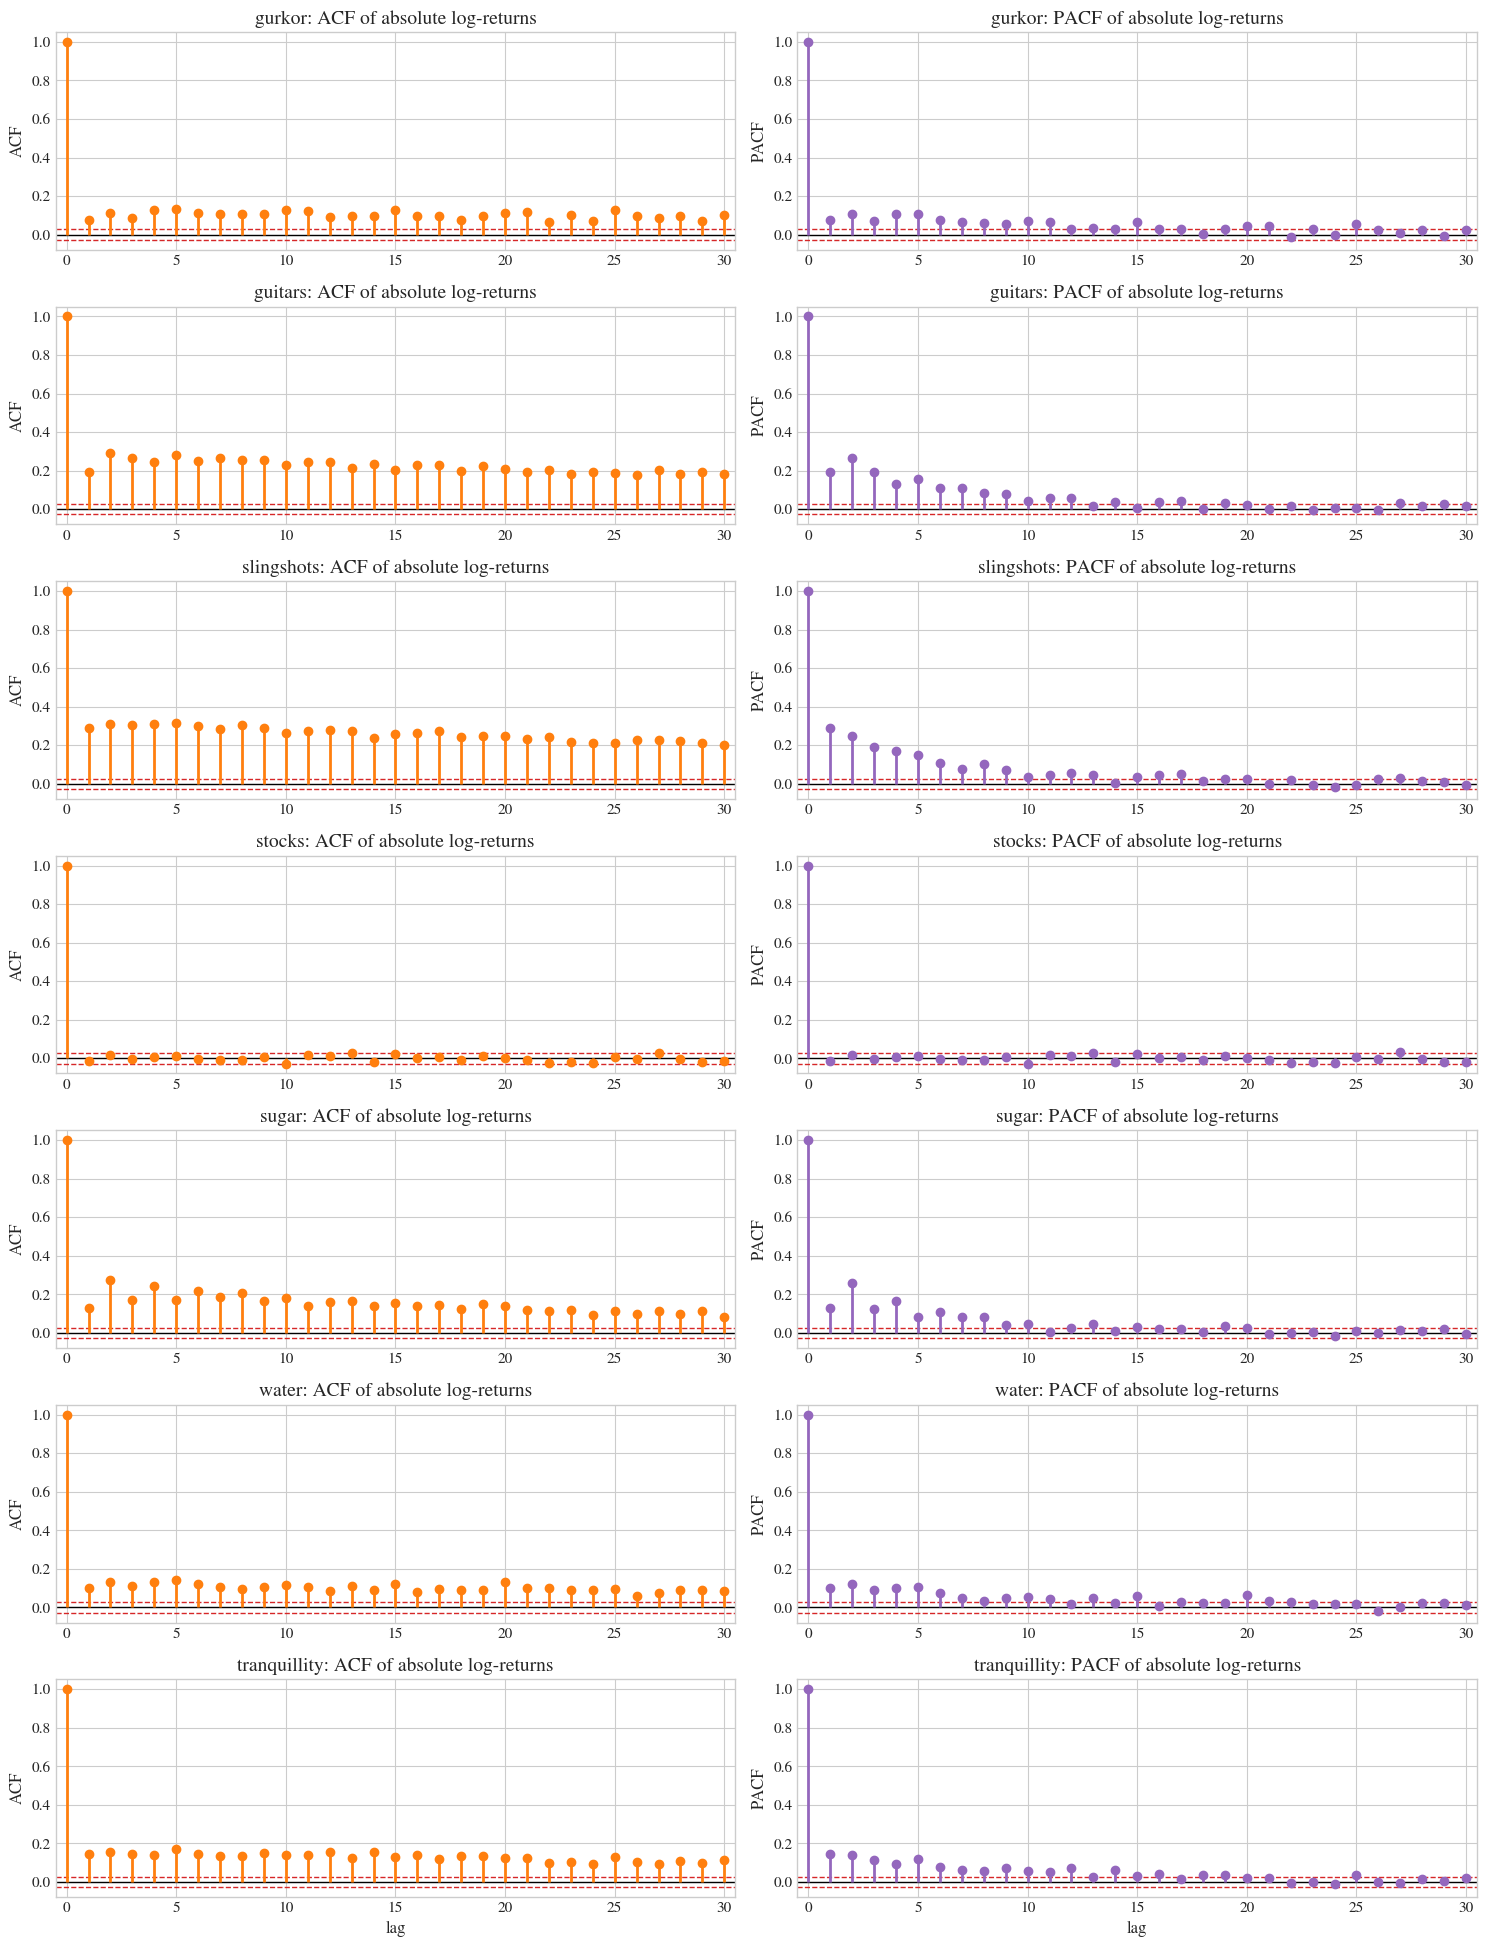

In [13]:
plot_dual_serial_correlation_grid(
    log_return_data,
    cleaned_data,
    max_lag=max_lag,
    label="log-returns",
    acf_color="tab:blue",
    pacf_color="tab:green",
)

plot_dual_serial_correlation_grid(
    absolute_log_return_data,
    cleaned_data,
    max_lag=max_lag,
    label="absolute log-returns",
    acf_color="tab:orange",
    pacf_color="tab:purple",
)


### Ljung-Box tests on transformed returns

The ACF gives a lag-by-lag picture of total dependence, while the PACF shows what remains after controlling for shorter lags. The Ljung-Box test instead asks whether a whole collection of autocorrelations is jointly close to zero. At lag horizon $h$,

$$
Q(h) = T(T+2) \sum_{k=1}^h \frac{\hat\rho_k^2}{T-k}.
$$

We run the test on $r_t$, $|r_t|$, and $r_t^2$. Small p-values mean that serial independence is not plausible at the chosen horizon.


In [16]:
ljung_box_returns = cleaned_data.ljung_box_summary(log_return_data)
ljung_box_absolute_returns = cleaned_data.ljung_box_summary(absolute_log_return_data)
ljung_box_squared_returns = cleaned_data.ljung_box_summary(squared_log_return_data)

ljung_box_table = pd.concat(
    [
        ljung_box_returns.add_prefix("log_return_"),
        ljung_box_absolute_returns.add_prefix("abs_log_return_"),
        ljung_box_squared_returns.add_prefix("sq_log_return_"),
    ],
    axis=1,
)
display(ljung_box_table)
ljung_box_table.reset_index().to_latex(output / "LjungBox.tex",index=False)


,log_return_lb_stat_lag_10,log_return_lb_pvalue_lag_10,log_return_lb_stat_lag_20,log_return_lb_pvalue_lag_20,abs_log_return_lb_stat_lag_10,abs_log_return_lb_pvalue_lag_10,abs_log_return_lb_stat_lag_20,abs_log_return_lb_pvalue_lag_20,sq_log_return_lb_stat_lag_10,sq_log_return_lb_pvalue_lag_10,sq_log_return_lb_stat_lag_20,sq_log_return_lb_pvalue_lag_20
series,,,,,,,,,,,,
gurkor,24.292282,6.861252e-03,41.821227,2.917785e-03,638.040342,1.235446e-130,1196.455112,4.282332e-241,364.343420,3.590312e-72,699.345490,3.044671e-135
guitars,24.792398,5.753211e-03,50.262117,2.031241e-04,3368.430980,0.000000e+00,5957.255520,0.000000e+00,2067.538629,0.000000e+00,3816.198729,0.000000e+00
slingshots,64.072608,6.095996e-10,78.169112,8.012434e-09,4610.621752,0.000000e+00,8151.395810,0.000000e+00,4827.406246,0.000000e+00,8173.363312,0.000000e+00
stocks,4.266790,9.345101e-01,12.476303,8.987075e-01,8.042204,6.247144e-01,21.365518,3.759062e-01,7.156975,7.105471e-01,17.746687,6.040910e-01
sugar,33.068825,2.652255e-04,43.071934,2.000040e-03,2056.092236,0.000000e+00,3169.436521,0.000000e+00,3928.036803,0.000000e+00,4921.069740,0.000000e+00
water,15.468068,1.159058e-01,22.077053,3.363442e-01,720.787002,2.161829e-148,1258.789680,1.968269e-254,465.358548,1.104060e-93,845.875885,2.549358e-166
tranquillity,11.903192,2.915877e-01,31.022005,5.490062e-02,1131.181687,9.997532e-237,2106.583569,0.000000e+00,661.908488,9.386927e-136,1255.538845,9.770200e-254


The comparison between $r_t$, $|r_t|$, and $r_t^2$ is especially important here. If the raw return series is close to uncorrelated but the transformed series are not, then the main signal is in volatility rather than in linear predictability of returns themselves.


## 6. Cross-series relationships

Task 1 also asks what relationships exist between the different assets. We therefore compare raw-price and return correlations, identify the strongest and weakest return pairs, and then look for broader groups.


In [17]:
price_correlation_matrix = cleaned_data.correlation_matrix(cleaned_prices)
return_correlation_matrix = cleaned_data.correlation_matrix(log_return_data)


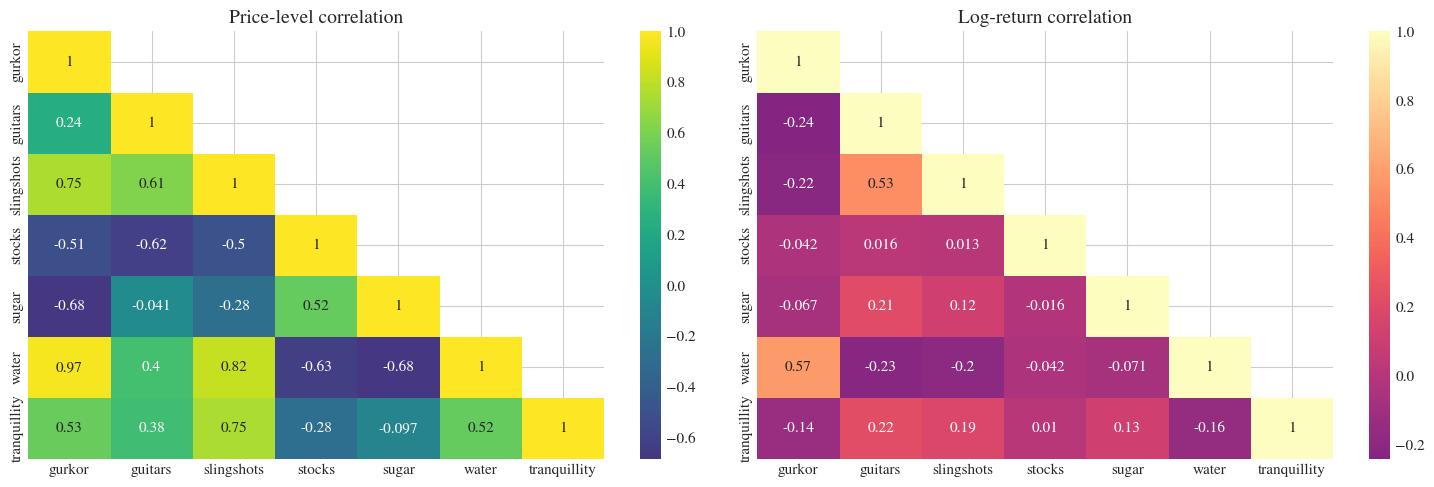

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), squeeze=False)
mask = np.triu(np.ones_like(price_correlation_matrix, dtype=bool), k=1)

sns.heatmap(price_correlation_matrix, annot=True, cmap="viridis", center=0, mask=mask, ax=axes[0, 0])
axes[0, 0].set_title("Price-level correlation")

sns.heatmap(return_correlation_matrix, annot=True, cmap="magma", center=0, mask=mask, ax=axes[0, 1])
axes[0, 1].set_title("Log-return correlation")

plt.tight_layout()
plt.savefig(output / "correlation_heatmaps.png", bbox_inches="tight")
plt.show()


In [19]:
return_pair_summary = cleaned_data.log_return_pair_summary()
display(return_pair_summary)


,asset_1,asset_2,log_return_correlation
least_correlated_pair,gurkor,guitars,-0.241075
most_correlated_pair,gurkor,water,0.573293


The pair summary is a compact way to answer which assets move together the most and which pair has the strongest negative comovement in returns.


### Grouping assets by log-return correlation

A simple first-pass grouping rule is to connect assets whenever their log-return correlation exceeds a chosen threshold. The threshold is not a law of nature, but it makes the grouping assumption explicit and easy to critique.


In [20]:
return_correlation_groups = cleaned_data.correlation_groups(log_return_data, threshold=group_threshold)
display(return_correlation_groups)


,group,group_members,group_size,avg_within_group_correlation
asset,,,,
guitars,1,"guitars, slingshots",2,0.526253
slingshots,1,"guitars, slingshots",2,0.526253
gurkor,2,"gurkor, water",2,0.573293
water,2,"gurkor, water",2,0.573293
stocks,3,stocks,1,NaN
sugar,4,sugar,1,NaN
tranquillity,5,tranquillity,1,NaN


### Dendrogram of asset similarity

To visualize the grouping more continuously, we also build a hierarchical clustering tree from the log-return correlations using the distance

$$
d_{ij} = 1 - \hat\rho_{ij}.
$$

Assets that merge at a low height are more similar. The lowest merges are the most informative; all assets eventually join the same tree at higher levels, so shared high branches should not be over-interpreted.


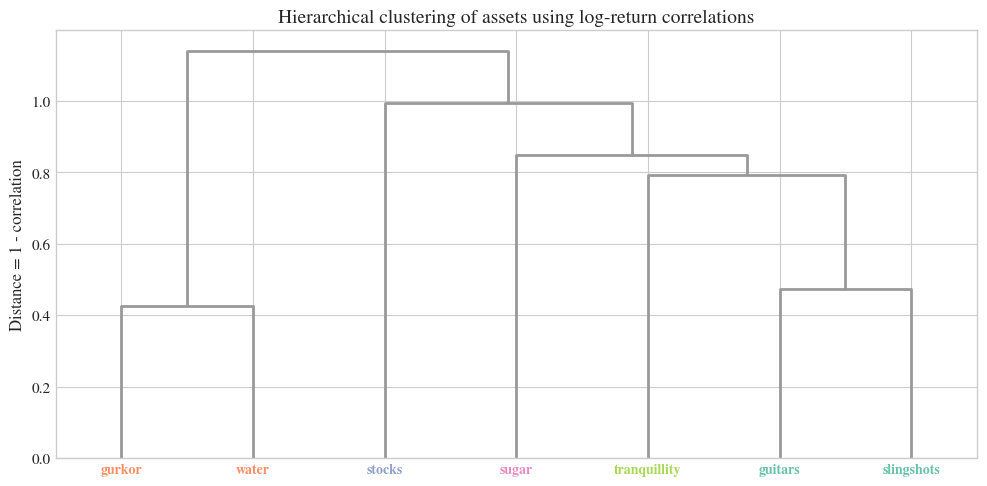

In [21]:
distance_matrix = (1 - return_correlation_matrix).clip(lower=0)
distance_array = distance_matrix.to_numpy(copy=True)
np.fill_diagonal(distance_array, 0.0)
condensed_distance = squareform(distance_array, checks=False)
linkage_matrix = linkage(condensed_distance, method="average")

group_ids = return_correlation_groups["group"].unique()
group_palette = sns.color_palette("Set2", n_colors=len(group_ids))
group_colors = dict(zip(group_ids, group_palette))
label_colors = {asset: group_colors[return_correlation_groups.loc[asset, "group"]] for asset in return_correlation_groups.index}

fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(
    linkage_matrix,
    labels=return_correlation_matrix.index.tolist(),
    leaf_rotation=0,
    leaf_font_size=10,
    color_threshold=0,
    above_threshold_color="0.6",
    ax=ax,
)

for tick in ax.get_xmajorticklabels():
    tick.set_color(label_colors[tick.get_text()])
    tick.set_fontweight("bold")

ax.set_title("Hierarchical clustering of assets using log-return correlations")
ax.set_ylabel("Distance = 1 - correlation")
plt.tight_layout()
plt.savefig(output / "return_correlation_dendrogram.png", bbox_inches="tight")
plt.show()


## 7. Combined comparison table

The final table gathers the main diagnostics in one place. This is useful for checking whether one common modeling strategy looks reasonable across all assets, or whether some series clearly behave differently from the rest.


In [22]:
comparison_summary = cleaned_data.series_comparison(window=rolling_window, max_lag=max_lag)
display(comparison_summary)


,raw_price_strongest_lag,raw_price_acf_at_strongest_lag,raw_price_significant_lags_up_to_30,log_return_strongest_lag,log_return_acf_at_strongest_lag,log_return_significant_lags_up_to_30,abs_log_return_strongest_lag,abs_log_return_acf_at_strongest_lag,abs_log_return_significant_lags_up_to_30,sq_log_return_strongest_lag,...,sq_log_return_significant_lags_up_to_30,lb_log_returns_pvalue_lag_10,lb_log_returns_pvalue_lag_20,lb_abs_returns_pvalue_lag_10,lb_abs_returns_pvalue_lag_20,lb_sq_returns_pvalue_lag_10,lb_sq_returns_pvalue_lag_20,return_mean,return_variance,avg_30d_return_variance
guitars,1,0.998359,30,26,-0.042821,8,2,0.294236,30,11,...,30,5.753211e-03,2.031241e-04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000236,0.000221,0.000224
slingshots,1,0.997486,30,1,-0.066867,8,5,0.314081,30,8,...,30,6.095996e-10,8.012434e-09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000194,0.000217,0.000219
sugar,1,0.998527,30,1,-0.049444,5,2,0.272644,30,2,...,30,2.652255e-04,2.000040e-03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-0.000014,0.000231,0.000232
water,1,0.999134,30,3,-0.038662,2,5,0.143166,30,20,...,30,1.159058e-01,3.363442e-01,2.161829e-148,1.968269e-254,1.104060e-93,2.549358e-166,0.000152,0.000012,0.000012
tranquillity,1,0.998411,30,14,0.043646,1,5,0.170896,30,12,...,30,2.915877e-01,5.490062e-02,9.997532e-237,0.000000e+00,9.386927e-136,9.770200e-254,0.000078,0.000158,0.000156
gurkor,1,0.999283,30,2,-0.044042,5,5,0.134493,30,21,...,29,6.861252e-03,2.917785e-03,1.235446e-130,4.282332e-241,3.590312e-72,3.044671e-135,0.000155,0.000016,0.000016
stocks,1,0.998486,30,20,-0.029241,1,13,0.029548,3,13,...,1,9.345101e-01,8.987075e-01,6.247144e-01,3.759062e-01,7.105471e-01,6.040910e-01,-0.000074,0.000223,0.000224


## 8. Conclusions

The notebook now covers all three parts emphasized in Task 1: within-series structure, cross-series relationships, and grouping.

Main conclusions:

- Cleaning matters immediately: there are 5 corrupted all-1000 rows, each series has one 50-day interior gap, and all series share a 200-day trailing gap. This directly shapes the interpolation and extrapolation problems in Tasks 2 and 3.
- The raw price levels are strongly persistent and should not be modeled directly. In the comparison table, every series has all 30 of the first raw-price ACF lags outside the noise band, which is exactly the pattern expected from nonstationary or highly persistent levels.
- The return series are much closer to stationary, but not equally so. `stocks` is the closest to serial independence in returns, with Ljung-Box p-values around 0.90 at lag 20 for $r_t$ and still non-significant for $|r_t|$ and $r_t^2$. `water` also has weak linear return dependence, but unlike `stocks` it still shows strong dependence in volatility proxies.
- Volatility clustering is the dominant signal in most series. Every asset except `stocks` strongly rejects independence in $|r_t|$ and $r_t^2$ at lag 20, so the main structure is often in the conditional variance rather than in the conditional mean.
- The strongest positive return pair is `gurkor`–`water` with correlation about 0.57, followed by `guitars`–`slingshots` at about 0.53. The strongest negative pair is `gurkor`–`guitars` at about -0.24.
- At the grouping threshold 0.3, the clearest comovement groups are `{gurkor, water}` and `{guitars, slingshots}`. `stocks`, `sugar`, and `tranquillity` remain singletons at that threshold, which suggests that the return dependence is concentrated in a few clear pairings rather than in one large common cluster.
- The variance levels differ substantially across assets. `water` and `gurkor` are much less volatile than `guitars`, `slingshots`, `stocks`, and `sugar`, so later modeling should not assume one common volatility scale across all series.
